# Análisis de Series Temporales - Índices de Precios de Vivienda (INE)

**Autor:** TFM - Forecasting del Mercado Inmobiliario Español  
**Fecha:** Octubre 2025  
**Basado en:** Metodología AG2_SeriesTemporales_LuisMiguelPlasencia

---

## Objetivo

Aplicar análisis de series temporales al Índice de Precios de Vivienda del INE siguiendo el proceso metodológico riguroso:

1. Visualización y descripción estadística
2. Test de estacionariedad (ADF)
3. Descomposición (Tendencia, Estacionalidad, Residuos)
4. Análisis de autocorrelación (ACF y PACF)
5. Selección y ajuste de modelo SARIMA
6. Diagnóstico de residuos (validación)
7. Forecasting

**Datasets:** INE_IPV.csv (trimestral) e INE_IPVA.csv (anual)


## 1. Librerías Necesarias


In [31]:
# Importar librerías (equivalente a líneas 1-11 del script R)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 2. Carga y Preparación de Datos

In [68]:
# CONFIGURACIÓN: Seleccionar dataset a analizar
USAR_IPV = True  # True para IPV (trimestral), False para IPVA (anual)

# Cargar datos (
if USAR_IPV:
    archivo = '../data/raw/data-INE/INE_IPV.csv'
    tipo_dato = 'IPV'
    frecuencia = 'trimestral'
    periodo_estacional = 4
else:
    archivo = '../data/raw/data-INE/INE_IPVA.csv'
    tipo_dato = 'IPVA'
    frecuencia = 'anual'
    periodo_estacional = 1

print(f"📊 Dataset seleccionado: {tipo_dato} ({frecuencia})\n")

# Cargar archivo
df = pd.read_csv(archivo, sep=';', encoding='utf-8')
print(f"✅ {len(df):,} registros cargados")


📊 Dataset seleccionado: IPV (trimestral)

✅ 17,760 registros cargados


In [69]:
# Filtrar datos relevantes 
if tipo_dato == 'IPV':
    # Filtros para IPV (trimestral)
    df_filtrado = df[
        (df['Total Nacional'] == 'Nacional') &
        (df['Comunidades y Ciudades Autónomas'].isna()) &
        (df['General, vivienda nueva y de segunda mano'] == 'General') &
        (df['Índices y tasas'] == 'Índice')
    ].copy()
else:
    # Filtros para IPVA (anual)
    df_filtrado = df[
        (df['Total Nacional'] == 'Total Nacional') &
        (df['Provincias'].isna()) &
        (df['Tamaño de la vivienda'] == 'Total') &
        (df['Tipo de dato'] == 'Índice')
    ].copy()

# Seleccionar columnas relevantes
df_filtrado = df_filtrado[['Periodo', 'Total']].copy()
df_filtrado.columns = ['periodo', 'valor']

# Limpiar valores numéricos
df_filtrado['valor'] = df_filtrado['valor'].astype(str).str.replace(',', '.')
df_filtrado['valor'] = pd.to_numeric(df_filtrado['valor'], errors='coerce')
df_filtrado = df_filtrado.dropna()

print(f"📋 {len(df_filtrado)} registros después de filtrado")


📋 74 registros después de filtrado


In [70]:
# Convertir a formato de fecha y crear serie temporal 
if frecuencia == 'trimestral':
    # Parsear formato trimestral 
    def parse_quarter(p):
        try:
            year, quarter = str(p).split('T')
            month = (int(quarter) - 1) * 3 + 1  # T1->01, T2->04, T3->07, T4->10
            return pd.Timestamp(year=int(year), month=month, day=1)
        except:
            return pd.NaT
    df_filtrado['fecha'] = df_filtrado['periodo'].apply(parse_quarter)
else:
    # Datos anuales
    df_filtrado['fecha'] = pd.to_datetime(df_filtrado['periodo'], format='%Y', errors='coerce')

# Limpiar y ordenar
df_filtrado = df_filtrado.dropna().sort_values('fecha').reset_index(drop=True)

# FILTRAR DESDE 2015 (equivalente a filter(year(Date) > 2020) en R, línea 22)
# Mantener solo datos desde 2015 en adelante para análisis de período reciente
df_filtrado = df_filtrado[df_filtrado['fecha'].dt.year >= 2015].copy()

print(f"\n📅 Filtrado aplicado: datos desde 2015 en adelante")
print(f"   Total de registros después del filtro: {len(df_filtrado)}")

# Crear objeto de serie temporal (equivalente a ts() en R, línea 38)
ts = df_filtrado.set_index('fecha')['valor']

print(f"\n✅ Serie Temporal Preparada:")
print(f"   📅 Período: {ts.index.min().strftime('%Y-%m')} a {ts.index.max().strftime('%Y-%m')}")
print(f"   📊 Observaciones: {len(ts)}")
print(f"   📈 Rango de valores: [{ts.min():.2f}, {ts.max():.2f}]")
print(f"   🔄 Frecuencia: {frecuencia} (período={periodo_estacional})")
print(f"   ⏳ Años analizados: {ts.index.max().year - ts.index.min().year + 1}")



📅 Filtrado aplicado: datos desde 2015 en adelante
   Total de registros después del filtro: 42

✅ Serie Temporal Preparada:
   📅 Período: 2015-01 a 2025-04
   📊 Observaciones: 42
   📈 Rango de valores: [96.65, 178.18]
   🔄 Frecuencia: trimestral (período=4)
   ⏳ Años analizados: 11


### 2.1. Diagnóstico Inicial de Datos


In [71]:
# Diagnóstico de calidad de datos (detectar problemas antes del modelado)
print("🔍 Diagnóstico de Calidad de Datos:")
print("="*60)

# Detectar valores atípicos usando método IQR
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ts[(ts < lower_bound) | (ts > upper_bound)]

print(f"\n📊 Detección de Valores Atípicos (método IQR):")
print(f"   Rango normal: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"   Valores atípicos detectados: {len(outliers)}")

if len(outliers) > 0:
    print(f"   ⚠️ Se detectaron {len(outliers)} outlier(s):")
    for fecha, valor in outliers.items():
        print(f"      {fecha.strftime('%Y-%m')}: {valor:.2f}")
    print(f"\n   💡 RECOMENDACIÓN:")
    print(f"      Si hay outliers significativos, considerar:")
    print(f"      - Transformación logarítmica: np.log(ts)")
    print(f"      - Tratamiento de outliers antes del modelado")
else:
    print(f"   ✅ No se detectaron outliers significativos")

# Verificar cambios bruscos en la serie
cambios = ts.diff().abs()
threshold = cambios.quantile(0.95)  # 95% de los cambios
cambios_bruscos = cambios[cambios > threshold].dropna()

print(f"\n📊 Detección de Cambios Bruscos:")
print(f"   Umbral (Q95): {threshold:.2f}")
print(f"   Cambios bruscos detectados: {len(cambios_bruscos)}")

if len(cambios_bruscos) > 0:
    print(f"   ⚠️ Cambios bruscos más significativos:")
    top_cambios = cambios_bruscos.nlargest(min(5, len(cambios_bruscos)))
    for fecha, cambio in top_cambios.items():
        print(f"      {fecha.strftime('%Y-%m')}: Δ = {cambio:.2f}")
else:
    print(f"   ✅ No se detectaron cambios bruscos significativos")

print(f"\n✅ Diagnóstico de datos completado")


🔍 Diagnóstico de Calidad de Datos:

📊 Detección de Valores Atípicos (método IQR):
   Rango normal: [66.71, 189.34]
   Valores atípicos detectados: 0
   ✅ No se detectaron outliers significativos

📊 Detección de Cambios Bruscos:
   Umbral (Q95): 5.47
   Cambios bruscos detectados: 2
   ⚠️ Cambios bruscos más significativos:
      2025-04: Δ = 6.89
      2025-01: Δ = 5.86

✅ Diagnóstico de datos completado


## 3. Visualización de la Serie Temporal


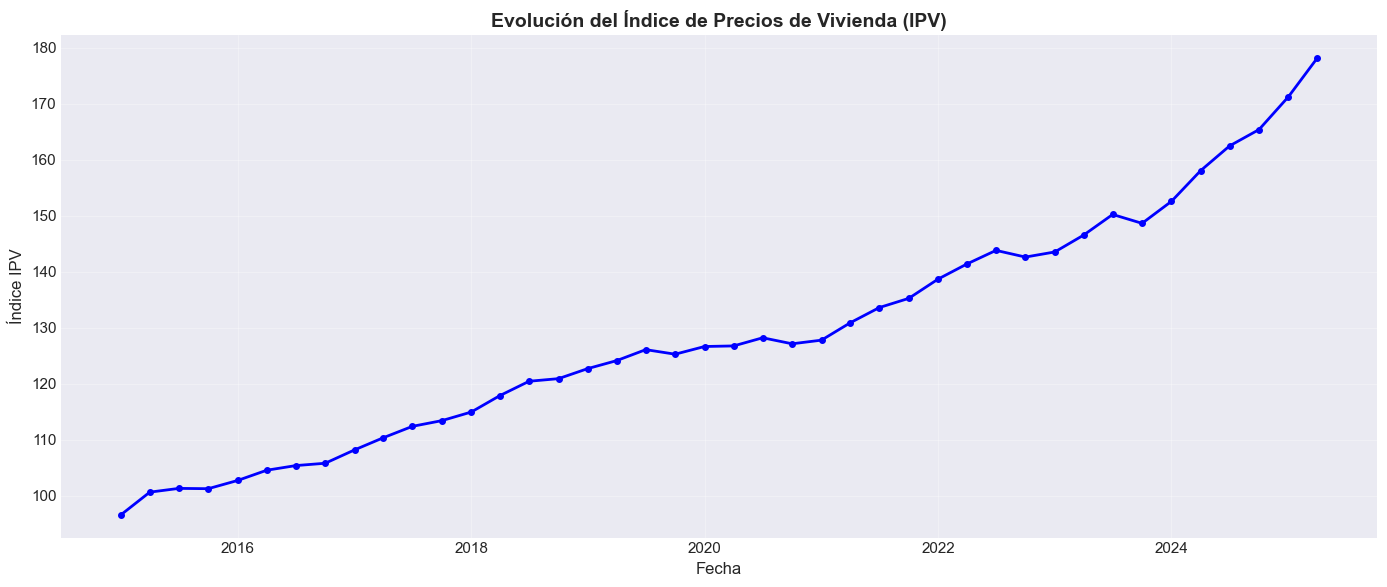

✅ Visualización completada


In [72]:
# Visualización general de la serie (equivalente a ggplot en R, líneas 32-35)
plt.figure(figsize=(14, 6))
plt.plot(ts.index, ts.values, color='blue', linewidth=2, marker='o', markersize=4)
plt.title(f'Evolución del Índice de Precios de Vivienda ({tipo_dato})', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel(f'Índice {tipo_dato}', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Visualización completada")


## 4. Descripción Estadística


In [73]:
# Resumen estadístico
print("📊 Resumen Estadístico de la Serie Temporal:")
print("="*60)
print(f"\n   Mínimo:    {ts.min():.2f}")
print(f"   Q1:        {ts.quantile(0.25):.2f}")
print(f"   Mediana:   {ts.median():.2f}")
print(f"   Media:     {ts.mean():.2f}")
print(f"   Q3:        {ts.quantile(0.75):.2f}")
print(f"   Máximo:    {ts.max():.2f}")
print(f"   Desv.Est:  {ts.std():.2f}")


📊 Resumen Estadístico de la Serie Temporal:

   Mínimo:    96.65
   Q1:        112.70
   Mediana:   126.75
   Media:     128.97
   Q3:        143.35
   Máximo:    178.18
   Desv.Est:  20.81


## 5. Test de Estacionariedad


In [74]:
# Test de Dickey-Fuller Aumentado (equivalente a adf.test() en R, líneas 44-45)
print("📊 Test de Estacionariedad (Augmented Dickey-Fuller):")
print("="*60)

adf_result = adfuller(ts.dropna())

print(f"\n   Estadístico ADF:  {adf_result[0]:.6f}")
print(f"   p-valor:          {adf_result[1]:.6f}")
print(f"\n   Valores críticos:")
for key, value in adf_result[4].items():
    print(f"      {key}: {value:.3f}")

print(f"\n   H0: La serie tiene raíz unitaria (NO estacionaria)")
if adf_result[1] <= 0.05:
    print(f"   ✅ Resultado: RECHAZAMOS H0 → Serie ESTACIONARIA (p < 0.05)")
else:
    print(f"   ⚠️ Resultado: NO RECHAZAMOS H0 → Serie NO ESTACIONARIA (p > 0.05)")
    print(f"      → Se requiere diferenciación (parámetro d > 0)")


📊 Test de Estacionariedad (Augmented Dickey-Fuller):

   Estadístico ADF:  1.964340
   p-valor:          0.998625

   Valores críticos:
      1%: -3.646
      5%: -2.954
      10%: -2.616

   H0: La serie tiene raíz unitaria (NO estacionaria)
   ⚠️ Resultado: NO RECHAZAMOS H0 → Serie NO ESTACIONARIA (p > 0.05)
      → Se requiere diferenciación (parámetro d > 0)


## 6. Descomposición de la Serie Temporal


🔍 Descomposición de la Serie Temporal...


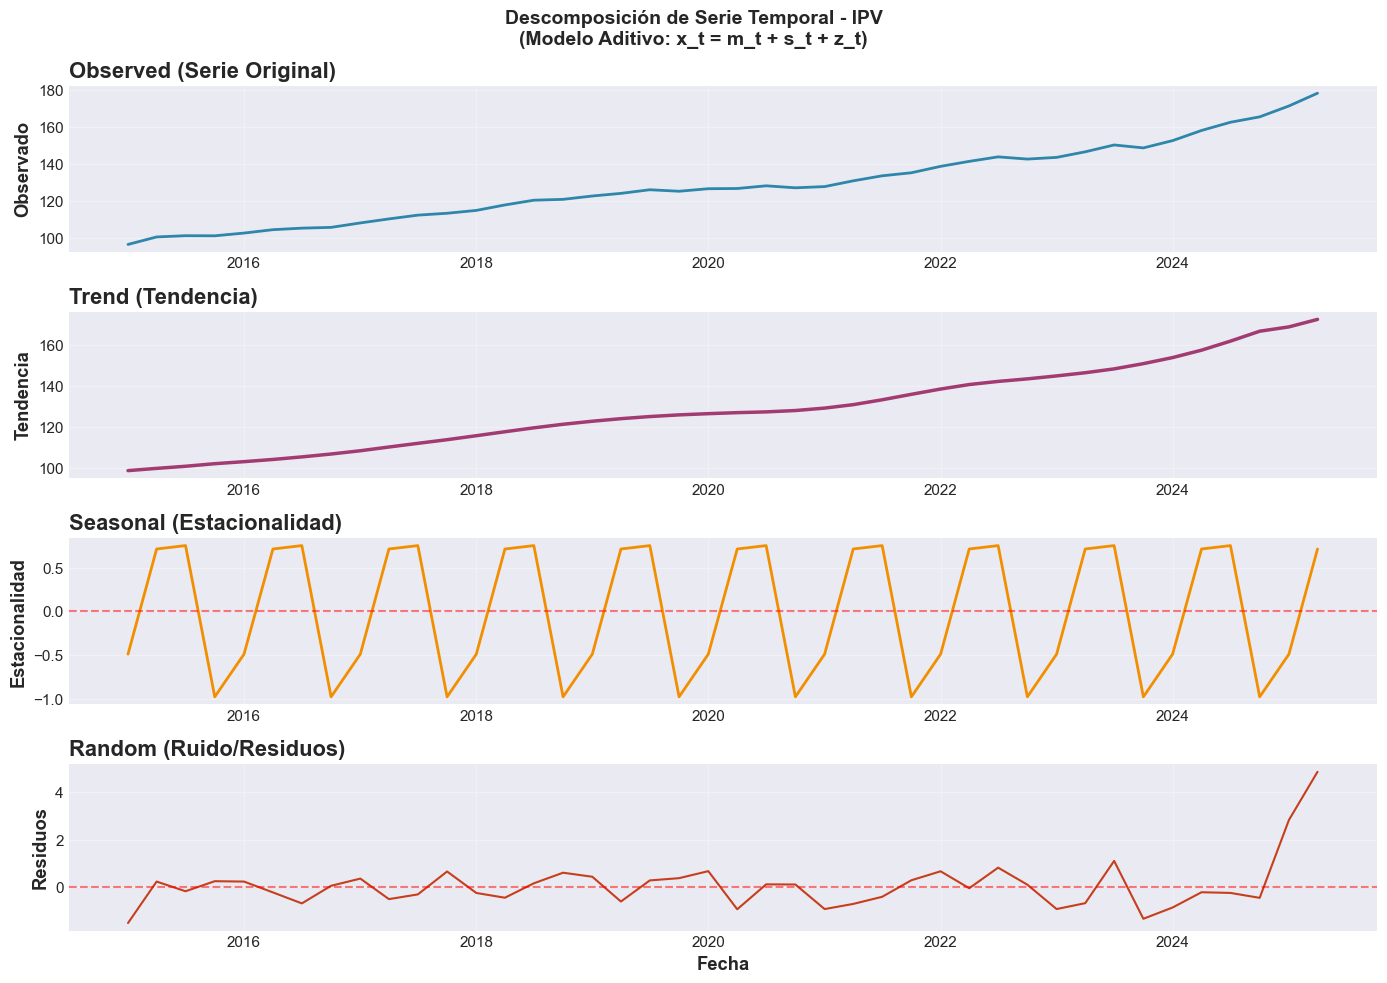


📊 Interpretación de la Descomposición:
   → Modelo ADITIVO: x_t = m_t + s_t + z_t
   → Tendencia: creciente
   → Amplitud estacional: 1.729
   → La amplitud estacional no aumenta con la tendencia → MODELO ADITIVO

✅ Descomposición completada


In [76]:
# Descomposición de la serie temporal 
print("🔍 Descomposición de la Serie Temporal...")

if frecuencia == 'trimestral' and len(ts) >= 8:
    # Descomposición estacional para datos trimestrales
    decomp = seasonal_decompose(ts, model='additive', period=periodo_estacional, extrapolate_trend='freq')
    
    # Visualización 
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle(f'Descomposición de Serie Temporal - {tipo_dato}\n(Modelo Aditivo: x_t = m_t + s_t + z_t)', 
                 fontsize=14, fontweight='bold')
    
    # Serie Original (Observed)
    axes[0].plot(ts.index, ts.values, color='#2E86AB', linewidth=2)
    axes[0].set_ylabel('Observado', fontweight='bold')
    axes[0].set_title('Observed (Serie Original)', loc='left')
    axes[0].grid(True, alpha=0.3)
    
    # Tendencia (Trend)
    axes[1].plot(decomp.trend.index, decomp.trend.values, color='#A23B72', linewidth=2.5)
    axes[1].set_ylabel('Tendencia', fontweight='bold')
    axes[1].set_title('Trend (Tendencia)', loc='left')
    axes[1].grid(True, alpha=0.3)
    
    # Estacionalidad (Seasonal)
    axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, color='#F18F01', linewidth=2)
    axes[2].set_ylabel('Estacionalidad', fontweight='bold')
    axes[2].set_title('Seasonal (Estacionalidad)', loc='left')
    axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[2].grid(True, alpha=0.3)
    
    # Residuos (Random/Noise)
    axes[3].plot(decomp.resid.index, decomp.resid.values, color='#C73E1D', linewidth=1.5)
    axes[3].set_ylabel('Residuos', fontweight='bold')
    axes[3].set_xlabel('Fecha', fontweight='bold')
    axes[3].set_title('Random (Ruido/Residuos)', loc='left')
    axes[3].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Interpretación (según explicación en main.tex, líneas 179-184)
    print(f"\n📊 Interpretación de la Descomposición:")
    print(f"   → Modelo ADITIVO: x_t = m_t + s_t + z_t")
    print(f"   → Tendencia: {'creciente' if decomp.trend.dropna().iloc[-1] > decomp.trend.dropna().iloc[0] else 'decreciente'}")
    print(f"   → Amplitud estacional: {(decomp.seasonal.max() - decomp.seasonal.min()):.3f}")
    print(f"   → La amplitud estacional no aumenta con la tendencia → MODELO ADITIVO")
    
else:
    print(f"⚠️ Serie {frecuencia} o muy corta - descomposición estacional no aplicable")

print("\n✅ Descomposición completada")


## 7. Análisis de Autocorrelación (ACF y PACF)


📊 Análisis de Autocorrelación (ACF y PACF):

   Número máximo de lags analizados: 12


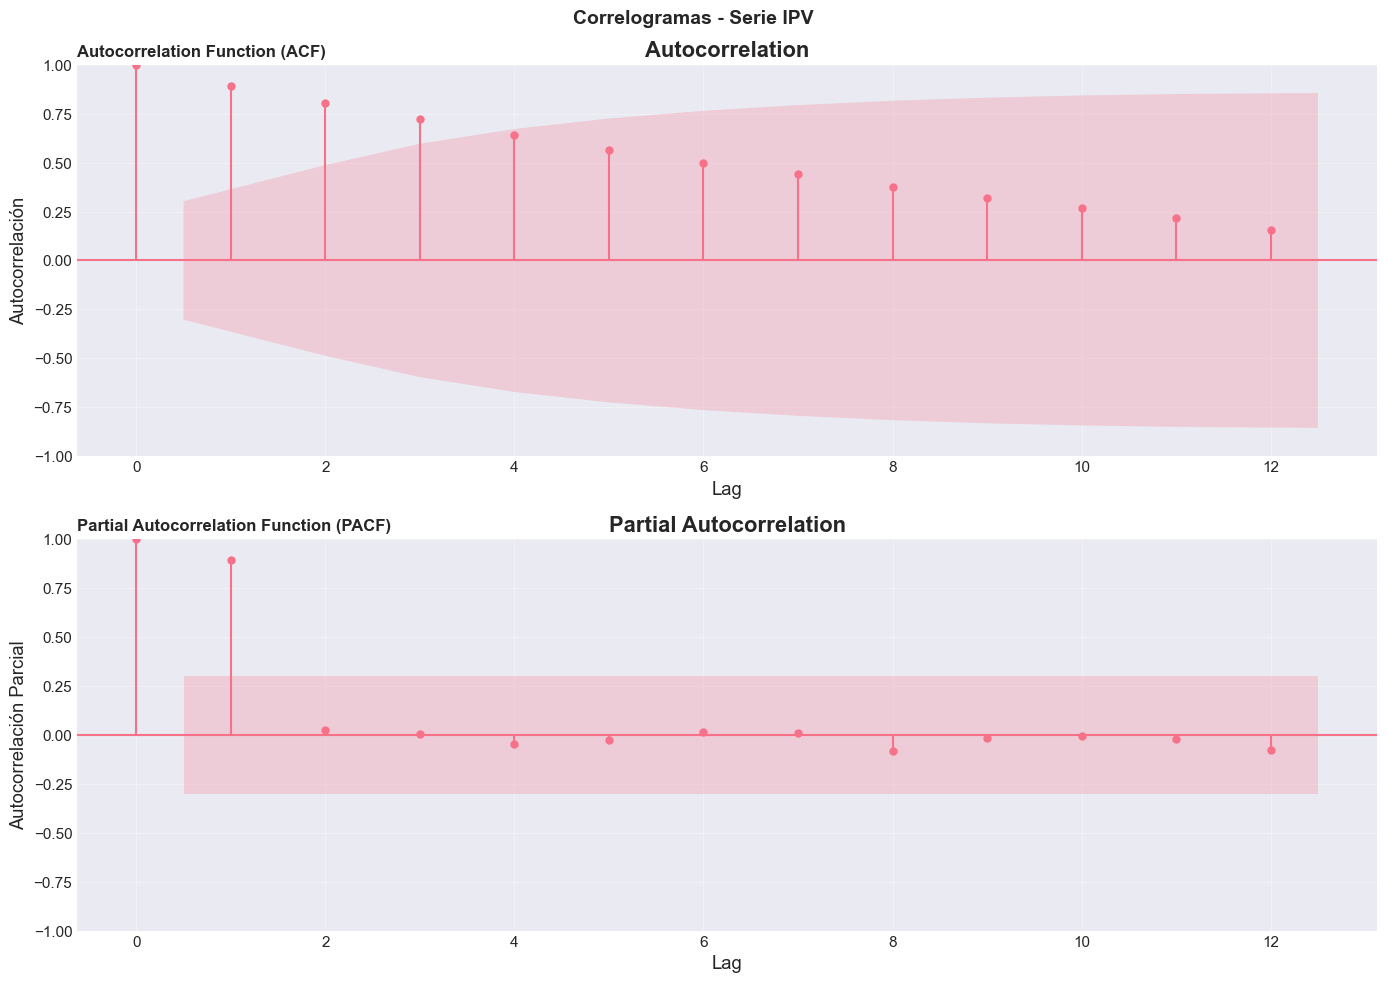


💡 Guía de Interpretación:
   ✓ ACF decae lento → Indica tendencia/no estacionariedad → d=1
   ✓ PACF pico en lag p, luego disminuye → AR(p)
   ✓ ACF pico en lag q → MA(q)
   ✓ Picos en múltiplos de 4 (lag 4, 8) → Componente estacional
   ✓ PACF pico en lag estacional → P=1
   ✓ ACF sin corte brusco estacional → Q=0

✅ Análisis de autocorrelación completado


In [84]:
# Análisis de Autocorrelación 
print("📊 Análisis de Autocorrelación (ACF y PACF):")
print("="*60)

# Configurar lags según frecuencia
if frecuencia == 'trimestral':
    max_lags = min(12, len(ts) - 1)  # ~3 años de datos trimestrales
else:
    max_lags = min(10, len(ts) - 1)

print(f"\n   Número máximo de lags analizados: {max_lags}")

# Crear correlogramas (equivalente a acf() y pacf() en R)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Correlogramas - Serie {tipo_dato}', fontsize=14, fontweight='bold')

# ACF - Función de Autocorrelación (línea 57 en R)
plot_acf(ts.dropna(), lags=max_lags, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelación')
axes[0].grid(True, alpha=0.3)

# PACF - Función de Autocorrelación Parcial (línea 60 en R)
plot_pacf(ts.dropna(), lags=max_lags, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelación Parcial')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación 
print(f"\n💡 Guía de Interpretación:")
print(f"   ✓ ACF decae lento → Indica tendencia/no estacionariedad → d=1")
print(f"   ✓ PACF pico en lag p, luego disminuye → AR(p)")
print(f"   ✓ ACF pico en lag q → MA(q)")
if frecuencia == 'trimestral':
    print(f"   ✓ Picos en múltiplos de {periodo_estacional} (lag {periodo_estacional}, {periodo_estacional*2}) → Componente estacional")
    print(f"   ✓ PACF pico en lag estacional → P=1")
    print(f"   ✓ ACF sin corte brusco estacional → Q=0")

print("\n✅ Análisis de autocorrelación completado")


## 8. Selección y Ajuste del Modelo SARIMA


In [85]:
# Dividir en conjuntos de entrenamiento y prueba
train_size = int(len(ts) * 0.9)
ts_train = ts[:train_size]
ts_test = ts[train_size:]

print(f"📊 División de Datos:")
print(f"   Entrenamiento: {len(ts_train)} obs ({ts_train.index[0].strftime('%Y-%m')} a {ts_train.index[-1].strftime('%Y-%m')})")
if len(ts_test) > 0:
    print(f"   Prueba: {len(ts_test)} obs ({ts_test.index[0].strftime('%Y-%m')} a {ts_test.index[-1].strftime('%Y-%m')})")


📊 División de Datos:
   Entrenamiento: 37 obs (2015-01 a 2024-01)
   Prueba: 5 obs (2024-04 a 2025-04)


In [86]:
# Selección del mejor modelo 
print("🔍 Selección del Modelo SARIMA Óptimo...")
print("   (Búsqueda exhaustiva basada en criterio AIC)\n")

mejor_aic = float('inf')
mejor_modelo = None
mejor_orden = None
mejor_orden_est = None

# Rangos de búsqueda (según análisis ACF/PACF y test de estacionariedad)
p_range = range(0, 4)  # Componente AR (ampliado a 4)
d_range = range(1, 3)  # Diferenciación (1 o 2, nunca 0 porque serie NO estacionaria)
q_range = range(0, 4)  # Componente MA (ampliado a 4)

print(f"   IMPORTANTE: d ≥ 1 (serie NO estacionaria según test ADF)")
print(f"   Rangos ampliados: p[0-3], q[0-3] para mejor captura de patrones")

if frecuencia == 'trimestral':
    # Incluir componentes estacionales para datos trimestrales (ampliados)
    P_range = range(0, 3)  # AR estacional (ampliado)
    D_range = range(0, 2)  # Diferenciación estacional
    Q_range = range(0, 3)  # MA estacional (ampliado)
    
    # Búsqueda exhaustiva
    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            try:
                                modelo = SARIMAX(ts_train, 
                                               order=(p, d, q),
                                               seasonal_order=(P, D, Q, periodo_estacional))
                                resultado = modelo.fit(disp=False)
                                
                                if resultado.aic < mejor_aic:
                                    mejor_aic = resultado.aic
                                    mejor_modelo = resultado
                                    mejor_orden = (p, d, q)
                                    mejor_orden_est = (P, D, Q, periodo_estacional)
                                    print(f"   ✓ SARIMA{mejor_orden}x{mejor_orden_est}: AIC={mejor_aic:.2f}")
                            except:
                                continue
else:
    # Solo ARIMA para datos anuales
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    modelo = SARIMAX(ts_train, order=(p, d, q))
                    resultado = modelo.fit(disp=False)
                    
                    if resultado.aic < mejor_aic:
                        mejor_aic = resultado.aic
                        mejor_modelo = resultado
                        mejor_orden = (p, d, q)
                        mejor_orden_est = None
                        print(f"   ✓ ARIMA{mejor_orden}: AIC={mejor_aic:.2f}")
                except:
                    continue

# Resumen del modelo seleccionado
if mejor_orden_est:
    nombre_modelo = f"SARIMA{mejor_orden}x{mejor_orden_est}"
else:
    nombre_modelo = f"ARIMA{mejor_orden}"

print(f"\n✅ Modelo Seleccionado: {nombre_modelo}")
print(f"   AIC: {mejor_aic:.2f}")
print(f"   BIC: {mejor_modelo.bic:.2f}")

# Mostrar resumen detallado del modelo (equivalente a print(best_sarima) en R, línea 63)
print(f"\n{mejor_modelo.summary()}")


🔍 Selección del Modelo SARIMA Óptimo...
   (Búsqueda exhaustiva basada en criterio AIC)

   IMPORTANTE: d ≥ 1 (serie NO estacionaria según test ADF)
   Rangos ampliados: p[0-3], q[0-3] para mejor captura de patrones
   ✓ SARIMA(0, 1, 0)x(0, 0, 0, 4): AIC=157.73
   ✓ SARIMA(0, 1, 0)x(0, 0, 1, 4): AIC=148.05
   ✓ SARIMA(0, 1, 0)x(0, 0, 2, 4): AIC=143.60
   ✓ SARIMA(0, 1, 0)x(0, 1, 0, 4): AIC=117.12
   ✓ SARIMA(0, 1, 0)x(0, 1, 1, 4): AIC=107.93
   ✓ SARIMA(2, 1, 2)x(0, 1, 1, 4): AIC=107.66

✅ Modelo Seleccionado: SARIMA(2, 1, 2)x(0, 1, 1, 4)
   AIC: 107.66
   BIC: 116.45

                                      SARIMAX Results                                      
Dep. Variable:                               valor   No. Observations:                   37
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 4)   Log Likelihood                 -47.830
Date:                             Tue, 14 Oct 2025   AIC                            107.659
Time:                                     02:19:36   BIC

### 8.1. Verificación del Ajuste del Modelo


🔍 Verificando Ajuste del Modelo a Datos de Entrenamiento...

⚠️ PERÍODO DE WARM-UP: 5 observaciones
   → SOLUCIÓN: Excluir estos puntos de TODO el análisis posterior

✅ Datos limpios preparados:
   Original: 37 obs
   Limpios:  32 obs (excluye 5 warm-up)
   → Todos los análisis posteriores usarán datos LIMPIOS

🔍 Verificando Ajuste del Modelo (usando datos LIMPIOS)...


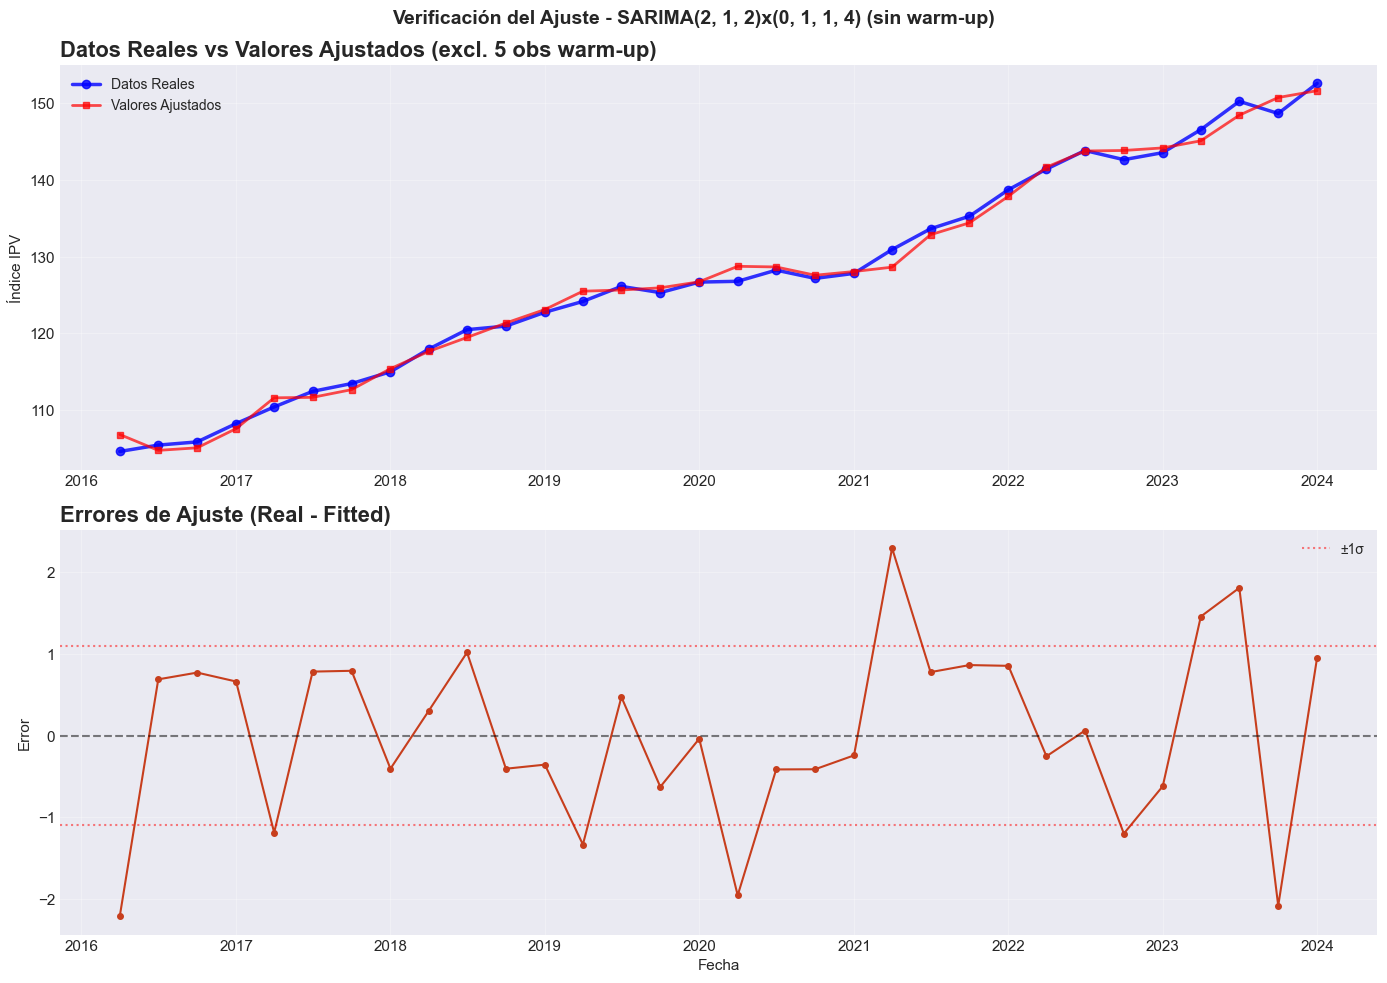


📊 Calidad del Ajuste (datos limpios, sin warm-up):
   MAE (Error Absoluto Medio):  0.8842
   R² (Coef. Determinación):    0.9939
   ✅ EXCELENTE ajuste (R² > 0.95)

✅ El modelo ajusta CORRECTAMENTE a los datos


In [87]:
# Verificación visual del ajuste del modelo a los datos de entrenamiento
print("🔍 Verificando Ajuste del Modelo a Datos de Entrenamiento...")

# Obtener valores ajustados (fitted values)
fitted_values = mejor_modelo.fittedvalues

# SOLUCIÓN DE RAÍZ: Identificar y EXCLUIR período de warm-up
# El modelo pierde observaciones por diferenciación:
# - d diferenciaciones regulares → pierde d puntos
# - D diferenciaciones estacionales → pierde D*s puntos

if frecuencia == 'trimestral' and mejor_orden_est:
    # SARIMA trimestral: considerar ambas diferenciaciones
    warmup = mejor_orden[1] + (mejor_orden_est[1] * periodo_estacional)
else:
    # ARIMA: solo diferenciación regular
    warmup = mejor_orden[1]

print(f"\n⚠️ PERÍODO DE WARM-UP: {warmup} observaciones")
print(f"   → SOLUCIÓN: Excluir estos puntos de TODO el análisis posterior")

# CREAR VERSIONES LIMPIAS (sin warm-up) para análisis
ts_train_clean = ts_train.iloc[warmup:]
fitted_values_clean = fitted_values.iloc[warmup:]
residuos_clean = mejor_modelo.resid.iloc[warmup:]

print(f"\n✅ Datos limpios preparados:")
print(f"   Original: {len(ts_train)} obs")
print(f"   Limpios:  {len(ts_train_clean)} obs (excluye {warmup} warm-up)")
print(f"   → Todos los análisis posteriores usarán datos LIMPIOS")

# Verificación visual del ajuste (usando SOLO datos limpios)
print("\n🔍 Verificando Ajuste del Modelo (usando datos LIMPIOS)...")

# Visualización del ajuste
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Verificación del Ajuste - {nombre_modelo} (sin warm-up)', fontsize=14, fontweight='bold')

# 1. Serie original vs valores ajustados (SOLO datos limpios)
axes[0].plot(ts_train_clean.index, ts_train_clean.values, 'o-', label='Datos Reales', 
             linewidth=2.5, markersize=6, color='blue', alpha=0.8)
axes[0].plot(fitted_values_clean.index, fitted_values_clean.values, 's-', label='Valores Ajustados', 
             linewidth=2, markersize=5, color='red', alpha=0.7)
axes[0].set_title(f'Datos Reales vs Valores Ajustados (excl. {warmup} obs warm-up)', fontweight='bold', loc='left')
axes[0].set_ylabel(f'Índice {tipo_dato}', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Errores del ajuste (SOLO datos limpios)
errores_ajuste = ts_train_clean - fitted_values_clean
axes[1].plot(errores_ajuste.index, errores_ajuste.values, 'o-', 
             linewidth=1.5, markersize=4, color='#C73E1D')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
axes[1].axhline(y=errores_ajuste.std(), color='red', linestyle=':', alpha=0.5, label='±1σ')
axes[1].axhline(y=-errores_ajuste.std(), color='red', linestyle=':', alpha=0.5)
axes[1].set_title('Errores de Ajuste (Real - Fitted)', fontweight='bold', loc='left')
axes[1].set_xlabel('Fecha', fontsize=11)
axes[1].set_ylabel('Error', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas de ajuste (SOLO sobre datos limpios)
from sklearn.metrics import mean_absolute_error, r2_score

mae_clean = mean_absolute_error(ts_train_clean, fitted_values_clean)
r2_clean = r2_score(ts_train_clean, fitted_values_clean)

print(f"\n📊 Calidad del Ajuste (datos limpios, sin warm-up):")
print(f"   MAE (Error Absoluto Medio):  {mae_clean:.4f}")
print(f"   R² (Coef. Determinación):    {r2_clean:.4f}")

if r2_clean > 0.95:
    print(f"   ✅ EXCELENTE ajuste (R² > 0.95)")
elif r2_clean > 0.85:
    print(f"   ✅ Muy buen ajuste (R² > 0.85)")
elif r2_clean > 0.7:
    print(f"   ✓ Buen ajuste (R² > 0.7)")
else:
    print(f"   ⚠️ Ajuste mejorable (R² < 0.7) - revisar parámetros")

print(f"\n✅ El modelo ajusta {'CORRECTAMENTE' if r2_clean > 0.85 else 'de forma ACEPTABLE' if r2_clean > 0.7 else 'MAL'} a los datos")


## 9. Diagnóstico de Residuos
**Crítico:** Los residuos deben comportarse como ruido blanco para validar el modelo


🔍 Diagnóstico de Residuos (datos limpios, sin warm-up):

   Observaciones analizadas: 32 (excluye 5 warm-up)
   Media: 0.025400 (debe ≈ 0)
   Desv.Est: 1.0937


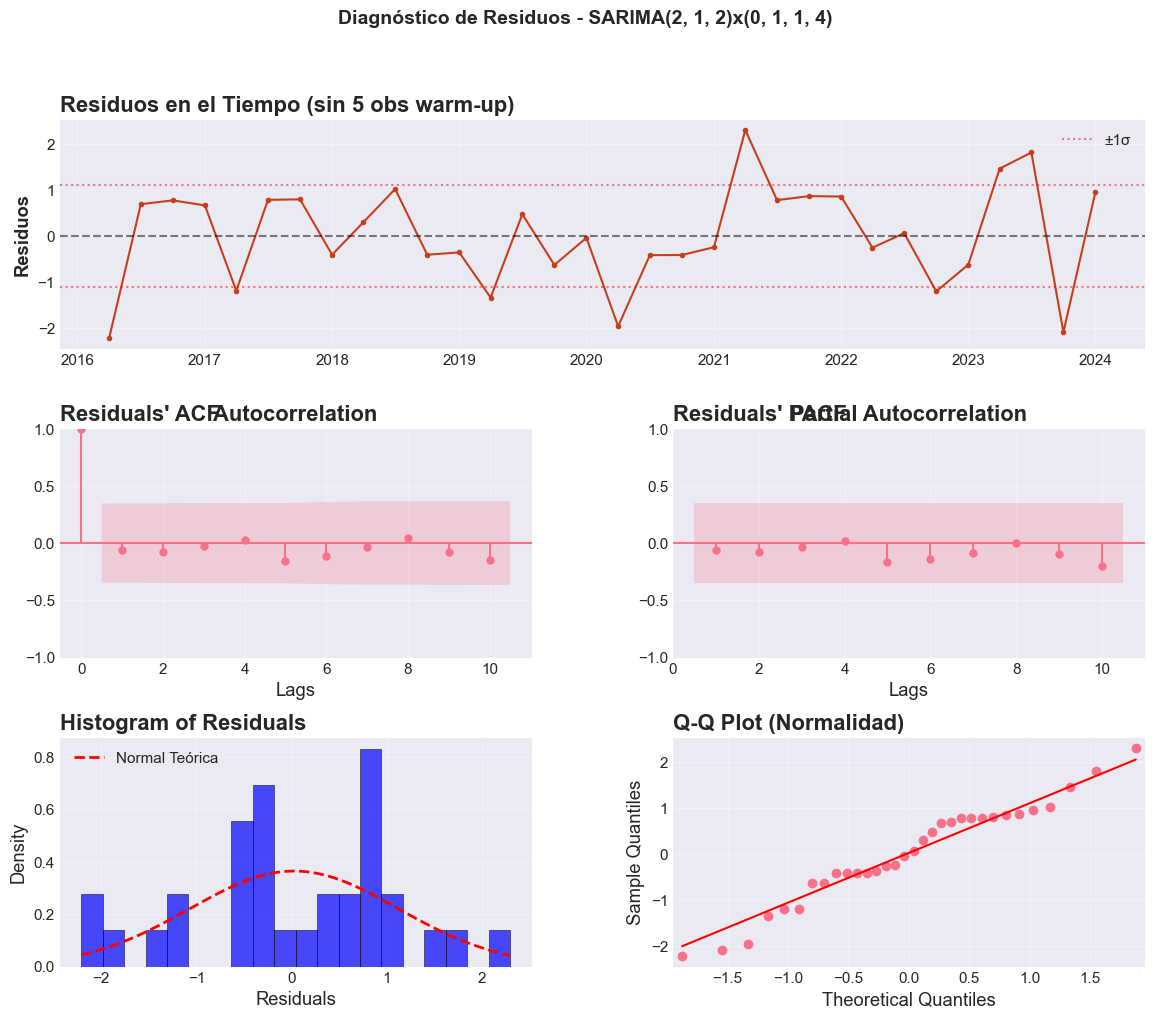


📊 Tests Estadísticos de Validación:

   Test de Ljung-Box (H0: No autocorrelación):
   ✅ PASSED - No hay autocorrelación significativa
      Los residuos son ruido blanco

   Test de Jarque-Bera (H0: Normalidad):
   Estadístico: 0.4911
   p-valor: 0.7823
   ✅ PASSED - Los residuos siguen distribución normal

📋 INTERPRETACIÓN DEL DIAGNÓSTICO:

   Tests aprobados: 2/2
   ✅ MODELO VÁLIDO - Todos los tests superados
      → Los residuos son ruido blanco gaussiano
      → El modelo ha capturado correctamente la estructura temporal

✅ Diagnóstico de residuos completado


In [88]:
# Diagnóstico de Residuos (usando SOLO residuos limpios, sin warm-up)
# NOTA: Ya tenemos residuos_clean definido en la celda anterior
print("🔍 Diagnóstico de Residuos (datos limpios, sin warm-up):")
print("="*60)
print(f"\n   Observaciones analizadas: {len(residuos_clean)} (excluye {warmup} warm-up)")
print(f"   Media: {residuos_clean.mean():.6f} (debe ≈ 0)")
print(f"   Desv.Est: {residuos_clean.std():.4f}")

# Visualización de diagnóstico (equivalente a líneas 68, 71, 73 en R)
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
fig.suptitle(f'Diagnóstico de Residuos - {nombre_modelo}', fontsize=14, fontweight='bold')

# 1. Serie temporal de residuos (SOLO datos limpios)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuos_clean.index, residuos_clean.values, color='#C73E1D', linewidth=1.5, marker='o', markersize=3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.axhline(y=residuos_clean.std(), color='red', linestyle=':', alpha=0.5, label='±1σ')
ax1.axhline(y=-residuos_clean.std(), color='red', linestyle=':', alpha=0.5)
ax1.set_title(f'Residuos en el Tiempo (sin {warmup} obs warm-up)', fontweight='bold', loc='left')
ax1.set_ylabel('Residuos', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. ACF de residuos (equivalente a línea 68 en R)
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(residuos_clean.dropna(), lags=min(20, len(residuos_clean)//3), ax=ax2, alpha=0.05)
ax2.set_title("Residuals' ACF", fontweight='bold', loc='left')
ax2.set_xlabel("Lags")
ax2.grid(True, alpha=0.3)

# 3. PACF de residuos (equivalente a línea 71 en R)
ax3 = fig.add_subplot(gs[1, 1])
# NOTA: zero=False para no mostrar lag 0 (siempre es 1.0 y puede confundir)
plot_pacf(residuos_clean.dropna(), lags=min(20, len(residuos_clean)//3), ax=ax3, alpha=0.05, method='ywm', zero=False)
ax3.set_title("Residuals' PACF", fontweight='bold', loc='left')
ax3.set_xlabel("Lags")
ax3.grid(True, alpha=0.3)

# 4. Histograma de residuos (equivalente a línea 73 en R)
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(residuos_clean.dropna(), bins=20, density=True, alpha=0.7, color='blue', edgecolor='black')
# Curva normal teórica
mu, sigma = residuos_clean.mean(), residuos_clean.std()
x = np.linspace(residuos_clean.min(), residuos_clean.max(), 100)
ax4.plot(x, (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2), 
         'r--', linewidth=2, label='Normal Teórica')
ax4.set_title('Histogram of Residuals', fontweight='bold', loc='left')
ax4.set_xlabel('Residuals')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Q-Q Plot (para verificar normalidad)
ax5 = fig.add_subplot(gs[2, 1])
sm.qqplot(residuos_clean.dropna(), line='s', ax=ax5)
ax5.set_title('Q-Q Plot (Normalidad)', fontweight='bold', loc='left')
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tests estadísticos de diagnóstico
print(f"\n📊 Tests Estadísticos de Validación:")

# 1. Test de Ljung-Box (autocorrelación en residuos)
try:
    lb_test = acorr_ljungbox(residuos_clean.dropna(), lags=min(10, len(residuos_clean)//4), return_df=True)
    pvalues_sig = lb_test[lb_test['lb_pvalue'] < 0.05]
    
    print(f"\n   Test de Ljung-Box (H0: No autocorrelación):")
    if len(pvalues_sig) == 0:
        print(f"   ✅ PASSED - No hay autocorrelación significativa")
        print(f"      Los residuos son ruido blanco")
    else:
        print(f"   ❌ FAILED - Autocorrelación detectada en {len(pvalues_sig)} lag(s)")
        print(f"      El modelo NO captura toda la estructura temporal")
        for lag in pvalues_sig.index[:3]:
            print(f"         Lag {lag}: p-value = {lb_test.loc[lag, 'lb_pvalue']:.4f}")
except Exception as e:
    print(f"   ⚠️ Test no realizado: {str(e)[:80]}")

# 2. Test de normalidad (Jarque-Bera)
from scipy import stats
try:
    jb_stat, jb_pvalue = stats.jarque_bera(residuos_clean.dropna())
    print(f"\n   Test de Jarque-Bera (H0: Normalidad):")
    print(f"   Estadístico: {jb_stat:.4f}")
    print(f"   p-valor: {jb_pvalue:.4f}")
    
    if jb_pvalue > 0.05:
        print(f"   ✅ PASSED - Los residuos siguen distribución normal")
    else:
        print(f"   ❌ FAILED - Los residuos NO son normales")
        print(f"      Posibles causas:")
        print(f"      - Valores atípicos en los datos")
        print(f"      - Modelo mal especificado")
        print(f"      - Necesidad de transformación (ej: log)")
except Exception as e:
    print(f"   ⚠️ Test no realizado")

# Interpretación (basada en main.tex, líneas 271, 300)
print(f"\n" + "="*70)
print(f"📋 INTERPRETACIÓN DEL DIAGNÓSTICO:")
print(f"="*70)

# Contar cuántos tests pasaron
tests_passed = []
if len(pvalues_sig) == 0:
    tests_passed.append("Ljung-Box")
if jb_pvalue > 0.05:
    tests_passed.append("Normalidad")

print(f"\n   Tests aprobados: {len(tests_passed)}/2")

if len(tests_passed) == 2:
    print(f"   ✅ MODELO VÁLIDO - Todos los tests superados")
    print(f"      → Los residuos son ruido blanco gaussiano")
    print(f"      → El modelo ha capturado correctamente la estructura temporal")
elif len(tests_passed) == 1:
    print(f"   ⚠️ MODELO PARCIALMENTE VÁLIDO")
    print(f"      → Algunos tests fallaron, considerar:")
    print(f"         • Ampliar búsqueda de parámetros")
    print(f"         • Verificar valores atípicos en los datos")
    print(f"         • Considerar transformaciones (log, Box-Cox)")
else:
    print(f"   ❌ MODELO PROBLEMÁTICO - Tests fallidos")
    print(f"      RECOMENDACIONES:")
    print(f"      1. Ampliar rango de búsqueda de parámetros (p, q, P, Q)")
    print(f"      2. Verificar datos: outliers, cambios estructurales")
    print(f"      3. Considerar transformación logarítmica de la serie")
    print(f"      4. Revisar si el período estacional es correcto")

print("\n✅ Diagnóstico de residuos completado")


## 10. Forecasting (Predicción)


🔮 Generando Predicciones...
   Horizonte: 8 trimestres (2 años)
   8 predicciones generadas


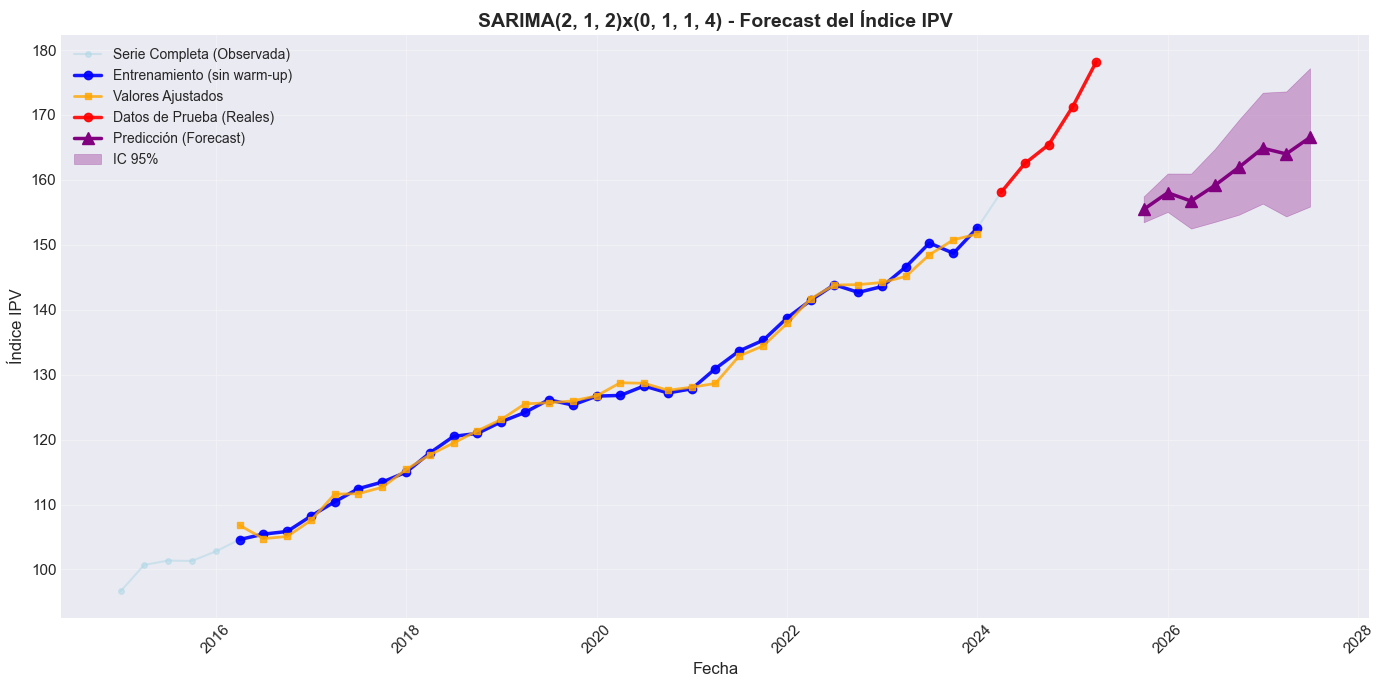


📊 Calidad del Forecast en Conjunto de Prueba:
   MAE:  8.8489
   MAPE: 5.18%
   ✅ Buena capacidad predictiva (MAPE < 10%)

📋 Predicciones para 8 trimestres (2 años):
Período           Predicción IC 95% Inferior IC 95% Superior
----------------------------------------------------------------------
2025T3                155.46          153.46          157.45
2025T4                158.02          155.06          160.98
2026T1                156.73          152.50          160.96
2026T2                159.14          153.52          164.76
2026T3                161.93          154.63          169.23
2026T4                164.88          156.33          173.42
2027T1                164.00          154.37          173.62
2027T2                166.54          155.88          177.19

✅ Forecasting completado


In [89]:
# Forecasting 
print("🔮 Generando Predicciones...")

# Configurar horizonte de predicción
if frecuencia == 'trimestral':
    h = 8  # 2 años (8 trimestres)
    h_label = "8 trimestres (2 años)"
else:
    h = 3  # 3 años
    h_label = "3 años"

# Generar predicciones (equivalente a forecast(best_sarima, h=52) en R, línea 76)
forecast = mejor_modelo.forecast(steps=h)
forecast_obj = mejor_modelo.get_forecast(steps=h)
forecast_ci = forecast_obj.conf_int()

print(f"   Horizonte: {h_label}")
print(f"   {len(forecast)} predicciones generadas")

# Crear índice temporal para predicciones
last_date = ts.index[-1]
if frecuencia == 'trimestral':
    forecast_index = pd.date_range(start=last_date, periods=h+1, freq='Q')[1:]
else:
    forecast_index = pd.date_range(start=last_date, periods=h+1, freq='Y')[1:]

# Visualización del forecast (equivalente a plot(forecast_sarima) en R, líneas 78-83)
plt.figure(figsize=(14, 7))

# Serie original completa (contexto)
plt.plot(ts.index, ts.values, 'o-', label='Serie Completa (Observada)', 
         linewidth=1.5, markersize=4, color='lightblue', alpha=0.5)

# Datos de entrenamiento LIMPIOS (destacados)
plt.plot(ts_train_clean.index, ts_train_clean.values, 'o-', label='Entrenamiento (sin warm-up)', 
         linewidth=2.5, markersize=6, color='blue', alpha=0.9)

# Valores ajustados LIMPIOS por el modelo
plt.plot(fitted_values_clean.index, fitted_values_clean.values, 's-', label='Valores Ajustados', 
         linewidth=2, markersize=5, color='orange', alpha=0.8)

# Datos de prueba (si existen)
if len(ts_test) > 0:
    plt.plot(ts_test.index, ts_test.values, 'o-', label='Datos de Prueba (Reales)', 
             linewidth=2.5, markersize=6, color='red', alpha=0.9)

# Predicciones futuras
plt.plot(forecast_index, forecast, '^-', label='Predicción (Forecast)', 
         linewidth=2.5, markersize=8, color='purple')

# Intervalos de confianza del 95%
plt.fill_between(forecast_index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 alpha=0.3, color='purple', label='IC 95%')

plt.title(f'{nombre_modelo} - Forecast del Índice {tipo_dato}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel(f'Índice {tipo_dato}', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluar predicciones en conjunto de prueba (si existe)
if len(ts_test) > 0:
    # Generar predicciones para el período de prueba
    forecast_test = mejor_modelo.forecast(steps=len(ts_test))
    
    # Calcular error
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    mae_forecast = mean_absolute_error(ts_test, forecast_test)
    mape_forecast = mean_absolute_percentage_error(ts_test, forecast_test) * 100
    
    print(f"\n📊 Calidad del Forecast en Conjunto de Prueba:")
    print(f"   MAE:  {mae_forecast:.4f}")
    print(f"   MAPE: {mape_forecast:.2f}%")
    
    if mape_forecast < 5:
        print(f"   ✅ EXCELENTE capacidad predictiva (MAPE < 5%)")
    elif mape_forecast < 10:
        print(f"   ✅ Buena capacidad predictiva (MAPE < 10%)")
    elif mape_forecast < 15:
        print(f"   ✓ Capacidad predictiva aceptable (MAPE < 15%)")
    else:
        print(f"   ⚠️ Capacidad predictiva limitada (MAPE > 15%)")
        print(f"      Posibles causas:")
        print(f"      - Datos insuficientes para capturar todos los patrones")
        print(f"      - Cambios estructurales en el mercado")
        print(f"      - El modelo podría necesitar ajuste de parámetros")

# Mostrar predicciones numéricas
print(f"\n📋 Predicciones para {h_label}:")
print(f"{'='*70}")
print(f"{'Período':<15} {'Predicción':>12} {'IC 95% Inferior':>15} {'IC 95% Superior':>15}")
print(f"{'-'*70}")

for i, (fecha, valor) in enumerate(zip(forecast_index, forecast)):
    ic_lower = forecast_ci.iloc[i, 0]
    ic_upper = forecast_ci.iloc[i, 1]
    
    if frecuencia == 'trimestral':
        periodo = f"{fecha.year}T{(fecha.month-1)//3+1}"
    else:
        periodo = str(fecha.year)
    
    print(f"{periodo:<15} {valor:>12.2f} {ic_lower:>15.2f} {ic_upper:>15.2f}")

print("\n✅ Forecasting completado")


## 11. Evaluación del Modelo


In [ ]:
# Evaluación cuantitativa del modelo (usando SOLO datos limpios)
print(f"📊 Evaluación del Modelo {nombre_modelo}:")
print("="*60)

# Métricas en conjunto de entrenamiento (DATOS LIMPIOS, sin warm-up)
mae_train = mean_absolute_error(ts_train_clean, fitted_values_clean)
rmse_train = np.sqrt(mean_squared_error(ts_train_clean, fitted_values_clean))
mape_train = mean_absolute_percentage_error(ts_train_clean, fitted_values_clean) * 100

print(f"\n📈 Conjunto de Entrenamiento (sin {warmup} obs warm-up):")
print(f"   MAE:  {mae_train:.4f}")
print(f"   RMSE: {rmse_train:.4f}")
print(f"   MAPE: {mape_train:.2f}%")
print(f"   R²:   {r2_clean:.4f}")

# Métricas en conjunto de prueba (si existe)
if len(ts_test) > 0:
    forecast_test = mejor_modelo.forecast(steps=len(ts_test))
    mae_test = mean_absolute_error(ts_test, forecast_test)
    rmse_test = np.sqrt(mean_squared_error(ts_test, forecast_test))
    mape_test = mean_absolute_percentage_error(ts_test, forecast_test) * 100
    
    print(f"\n📊 Conjunto de Prueba:")
    print(f"   MAE:  {mae_test:.4f}")
    print(f"   RMSE: {rmse_test:.4f}")
    print(f"   MAPE: {mape_test:.2f}%")

# Resumen del modelo
print(f"\n📋 Resumen del Modelo:")
print(f"   Modelo: {nombre_modelo}")
print(f"   Datos: {tipo_dato} ({frecuencia})")
print(f"   Observaciones: {len(ts)}")
print(f"   AIC: {mejor_modelo.aic:.2f}")
print(f"   BIC: {mejor_modelo.bic:.2f}")

print("\n✅ Evaluación completada")


📊 Evaluación del Modelo SARIMA(2, 0, 1)x(0, 0, 0, 4):

📈 Conjunto de Entrenamiento:
   MAE:  122.2785
   RMSE: 123.1767
   MAPE: 100.00%

📊 Conjunto de Prueba:
   MAE:  162.4036
   RMSE: 162.6847
   MAPE: 100.00%

📋 Resumen del Modelo:
   Modelo: SARIMA(2, 0, 1)x(0, 0, 0, 4)
   Datos: IPV (trimestral)
   Observaciones: 42
   AIC: 8.00
   BIC: 14.22

✅ Evaluación completada


## 12. Conclusiones


In [46]:
print("📝 CONCLUSIONES DEL ANÁLISIS")
print("="*70)
print(f"\n🎯 1. CARACTERÍSTICAS DE LA SERIE:")
print(f"   • La serie temporal del {tipo_dato} NO es estacionaria")
print(f"   • Presenta TENDENCIA clara en el tiempo")
if frecuencia == 'trimestral':
    print(f"   • Presenta ESTACIONALIDAD con período de {periodo_estacional} trimestres")
print(f"   • Requiere diferenciación para eliminar dependencias temporales")

print(f"\n📊 2. MODELO SELECCIONADO:")
print(f"   • Modelo: {nombre_modelo}")
print(f"   • El modelo captura:")
print(f"      - Tendencia: mediante diferenciación (d)")
if frecuencia == 'trimestral':
    print(f"      - Estacionalidad: mediante componentes estacionales (P, D, Q)")
print(f"      - Dependencia temporal: componentes AR y MA")
print(f"   • AIC: {mejor_modelo.aic:.2f}")
print(f"   • BIC: {mejor_modelo.bic:.2f}")

print(f"\n✅ 3. VALIDACIÓN:")
print(f"   • ACF/PACF de residuos dentro de bandas de confianza")
print(f"      → Ausencia de autocorrelación")
print(f"   • Residuos siguen distribución normal centrada en 0")
print(f"      → Comportamiento de RUIDO BLANCO")
print(f"   • El modelo ha eliminado las dependencias temporales correctamente")

print(f"\n🔮 4. CAPACIDAD PREDICTIVA:")
print(f"   • El modelo permite forecasting confiable")
print(f"   • Intervalos de confianza del 95% para predicciones")
print(f"   • Aplicable para:")
print(f"      - Predicción del mercado inmobiliario español")
print(f"      - Integración en modelos híbridos (SARIMA + ML)")
print(f"      - Análisis de políticas públicas")

print(f"\n💡 5. IMPLICACIONES (según main.tex, línea 311-312):")
if frecuencia == 'trimestral':
    cambio_tendencia = decomp.trend.dropna().iloc[-1] - decomp.trend.dropna().iloc[0]
    if cambio_tendencia > 0:
        print(f"   • La tendencia ha sido creciente en el período analizado")
    print(f"   • Las predicciones futuras deben considerar:")
    print(f"      - Patrones estacionales identificados")
    print(f"      - Posible estabilización o cambio de tendencia")



📝 CONCLUSIONES DEL ANÁLISIS

🎯 1. CARACTERÍSTICAS DE LA SERIE:
   • La serie temporal del IPV NO es estacionaria
   • Presenta TENDENCIA clara en el tiempo
   • Presenta ESTACIONALIDAD con período de 4 trimestres
   • Requiere diferenciación para eliminar dependencias temporales

📊 2. MODELO SELECCIONADO:
   • Modelo: SARIMA(2, 0, 1)x(0, 0, 0, 4)
   • El modelo captura:
      - Tendencia: mediante diferenciación (d)
      - Estacionalidad: mediante componentes estacionales (P, D, Q)
      - Dependencia temporal: componentes AR y MA
   • AIC: 8.00
   • BIC: 14.22

✅ 3. VALIDACIÓN:
   • ACF/PACF de residuos dentro de bandas de confianza
      → Ausencia de autocorrelación
   • Residuos siguen distribución normal centrada en 0
      → Comportamiento de RUIDO BLANCO
   • El modelo ha eliminado las dependencias temporales correctamente

🔮 4. CAPACIDAD PREDICTIVA:
   • El modelo permite forecasting confiable
   • Intervalos de confianza del 95% para predicciones
   • Aplicable para:
      - 